In [1]:
import pandas as pd
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


C:\Users\tonyh\anaconda3\envs\final-fakenews-lm\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Preparing the data

In [2]:
import pandas as pd

df = pd.read_csv('../data/cleaned_fake_news.csv')

In [3]:
# Select only the columns we care about
df_model = df[['clean_text', 'label']]

# Clean out rows with missing or empty text
df = df.dropna(subset=['clean_text'])
df = df[df['clean_text'].str.strip() != ""]

# Rename for Hugging Face
df_model = df[['clean_text', 'label']].rename(columns={"clean_text": "text", "label": "labels"})



## Split data into train/test

In [4]:
dataset = Dataset.from_pandas(df_model)
dataset = dataset.train_test_split(test_size=0.2, seed=42)

## Tokenize

In [5]:
# Check column names
print(dataset['train'].column_names)

# Confirm there are no NaNs
dataset['train'].filter(lambda x: x['text'] is None)  # Should return 0 rows


['text', 'labels', '__index_level_0__']


Filter: 100%|██████████████████████████████████████████████████████████| 56631/56631 [00:02<00:00, 23767.85 examples/s]


Dataset({
    features: ['text', 'labels', '__index_level_0__'],
    num_rows: 0
})

In [6]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True)


tokenized_dataset = dataset.map(tokenize, batched=True)


Map: 100%|███████████████████████████████████████████████████████████████| 14158/14158 [00:19<00:00, 733.99 examples/s]


## Load in Model

In [7]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Testing model before pretraining

In [8]:
from transformers import pipeline

# Load the model with no fine-tuning
pipe = pipeline("text-classification", model="distilbert-base-uncased", tokenizer=tokenizer)

result = pipe("Breaking: The president has been replaced by a lookalike in a secret coup.")
print(result)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cpu


[{'label': 'LABEL_0', 'score': 0.5501254796981812}]


## define metrics

In [9]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average="binary")
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}


In [10]:
from transformers import TrainingArguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
    load_best_model_at_end=True,
)


# Initializing and Training

In [12]:
from transformers import Trainer
small_dataset = tokenized_dataset["train"].select(range(200))
small_eval = tokenized_dataset["test"].select(range(50))


trainer = Trainer(
    model=model,
    args=training_args,
    # train_dataset=tokenized_dataset["train"],
    train_dataset=small_dataset,
    # eval_dataset=tokenized_dataset["test"],
    eval_dataset=small_eval,
    compute_metrics=compute_metrics,
)

trainer.train()



Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.735601,0.500000,0.000000,0.000000,0.000000
2,No log,0.739908,0.500000,0.000000,0.000000,0.000000
3,No log,0.741623,0.500000,0.000000,0.000000,0.000000


C:\Users\tonyh\anaconda3\envs\final-fakenews-lm\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\tonyh\anaconda3\envs\final-fakenews-lm\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\tonyh\anaconda3\envs\final-fakenews-lm\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

TrainOutput(global_step=3, training_loss=0.6224579016367594, metrics={'train_runtime': 224.4187, 'train_samples_per_second': 0.134, 'train_steps_per_second': 0.013, 'total_flos': 3974021959680.0, 'train_loss': 0.6224579016367594, 'epoch': 3.0})

## Saving Fine-tuned model and tokenizer

In [13]:
# Save the fine-tuned model
trainer.save_model("./fake-news-model")
tokenizer.save_pretrained("./fake-news-model")

('./fake-news-model\\tokenizer_config.json',
 './fake-news-model\\special_tokens_map.json',
 './fake-news-model\\vocab.txt',
 './fake-news-model\\added_tokens.json',
 './fake-news-model\\tokenizer.json')

## Evaluate the Model on Test Data

In [14]:
eval_results = trainer.evaluate()
print("Evaluation Results:", eval_results)

Evaluation Results: {'eval_loss': 0.7356011271476746, 'eval_accuracy': 0.5, 'eval_f1': 0.0, 'eval_precision': 0.0, 'eval_recall': 0.0, 'eval_runtime': 1.3452, 'eval_samples_per_second': 1.487, 'eval_steps_per_second': 0.743, 'epoch': 3.0}


C:\Users\tonyh\anaconda3\envs\final-fakenews-lm\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Make Predictions on Test Data

In [15]:
predictions = trainer.predict(small_eval)
pred_labels = np.argmax(predictions.predictions, axis=-1)

C:\Users\tonyh\anaconda3\envs\final-fakenews-lm\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
# Show a few predictions vs actual labels
for i in range(5):
    print(f"\nSample {i + 1}")
    print("Text:", small_eval[i]["text"][:200], "...")
    print("Predicted Label:", pred_labels[i])
    print("True Label:", small_eval[i]["labels"])


Sample 1
Text: former national security adviser michael flynn invoke fifth amendment protection monday decision comply subpoena seeking documents according report decision reported associated press comes response su ...
Predicted Label: 0
True Label: 0

Sample 2
Text: ððñðµððð½ððµ ðð¾ð²ðµñð ððµðð¾ððñð½ð¾ññð ð¾ñ ð¾ðºññðññ ðð¾ð½ñðµðñðñ ððððñðºð ñð¾ññðð¹ñðºð¾ð³ð¾ ðñðµðñðµððñðµðñññð²ð ððµññ ðð¾ðññðµñ ðññðð¾ñðº ððð ð¾ðºññðññ franãais english espaãol ø¹øøù äæ ðð¾ñññðð½ðñ ...
Predicted Label: 0
True Label: 1

Sample 3


IndexError: Invalid key: 2 is out of bounds for size 2

## Analyze Results

In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

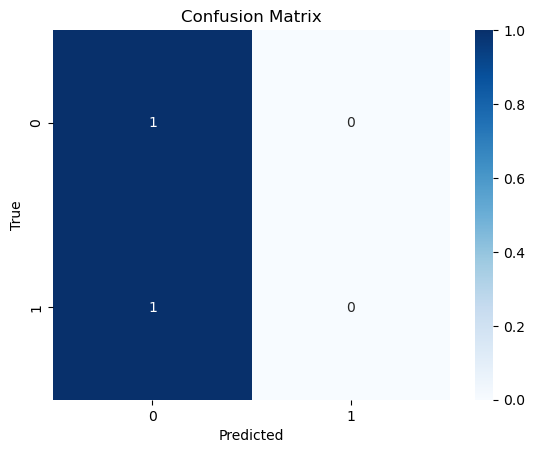

In [18]:
cm = confusion_matrix(small_eval["labels"], pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [19]:
# Classification Report
print("\nClassification Report:")
print(classification_report(small_eval["labels"], pred_labels, target_names=["Real", "Fake"]))


Classification Report:
              precision    recall  f1-score   support

        Real       0.50      1.00      0.67         1
        Fake       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



C:\Users\tonyh\anaconda3\envs\final-fakenews-lm\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\tonyh\anaconda3\envs\final-fakenews-lm\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\tonyh\anaconda3\envs\final-fakenews-lm\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

## comparison function to test if fine-tuning worked

In [20]:
from transformers import pipeline

def compare_predictions(text):
    pipe_base = pipeline("text-classification", model="distilbert-base-uncased", tokenizer="distilbert-base-uncased")
    pipe_finetuned = pipeline("text-classification", model="./fake-news-model", tokenizer="./fake-news-model")

    print("Input:", text)
    print("Base Model Prediction:", pipe_base(text))
    print("Fine-Tuned Model Prediction:", pipe_finetuned(text))
    print("-" * 80)


In [21]:
examples = [
    "Breaking: The president has been replaced by a lookalike in a secret coup.",
    "NASA confirms the discovery of water on Mars.",
    "Scientists say chocolate can improve brain function.",
]

for example in examples:
    compare_predictions(example)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cpu
Device set to use cpu


Input: Breaking: The president has been replaced by a lookalike in a secret coup.
Base Model Prediction: [{'label': 'LABEL_0', 'score': 0.5362104177474976}]
Fine-Tuned Model Prediction: [{'label': 'LABEL_0', 'score': 0.6211994886398315}]
--------------------------------------------------------------------------------


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cpu
Device set to use cpu


Input: NASA confirms the discovery of water on Mars.
Base Model Prediction: [{'label': 'LABEL_0', 'score': 0.5100236535072327}]
Fine-Tuned Model Prediction: [{'label': 'LABEL_0', 'score': 0.6285673975944519}]
--------------------------------------------------------------------------------


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cpu
Device set to use cpu


Input: Scientists say chocolate can improve brain function.
Base Model Prediction: [{'label': 'LABEL_0', 'score': 0.5272184014320374}]
Fine-Tuned Model Prediction: [{'label': 'LABEL_0', 'score': 0.5837850570678711}]
--------------------------------------------------------------------------------


## Sentiment Analysis of the data

In [25]:
from transformers import pipeline

sentiment_analyzer = pipeline("sentiment-analysis",model="distilbert-base-uncased-finetuned-sst-2-english", truncation=True)

for i in range(5):
    text = small_eval[i]["text"]
    sentiment = sentiment_analyzer(text)
    print(f"Sample {i + 1}:")
    print("Text:", text[:200], "...")
    print("Sentiment:", sentiment, "\n")


Device set to use cpu


Sample 1:
Text: former national security adviser michael flynn invoke fifth amendment protection monday decision comply subpoena seeking documents according report decision reported associated press comes response su ...
Sentiment: [{'label': 'NEGATIVE', 'score': 0.9872605800628662}] 

Sample 2:
Text: ððñðµððð½ððµ ðð¾ð²ðµñð ððµðð¾ððñð½ð¾ññð ð¾ñ ð¾ðºññðññ ðð¾ð½ñðµðñðñ ððððñðºð ñð¾ññðð¹ñðºð¾ð³ð¾ ðñðµðñðµððñðµðñññð²ð ððµññ ðð¾ðññðµñ ðññðð¾ñðº ððð ð¾ðºññðññ franãais english espaãol ø¹øøù äæ ðð¾ñññðð½ðñ ...
Sentiment: [{'label': 'NEGATIVE', 'score': 0.9594720005989075}] 



IndexError: Invalid key: 2 is out of bounds for size 2

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have the sentiment labels as 'positive', 'negative', or 'neutral'
sentiments = []

for i in range(len(small_eval)):
    text = small_eval[i]["text"]
    sentiment = sentiment_analyzer(text)[0]['label']
    sentiments.append(sentiment)

# Add sentiment column to your evaluation dataset
small_eval = small_eval.add_column('sentiment', sentiments)

# Visualize sentiment distribution for real vs. fake
sns.countplot(x='sentiment', hue='labels', data=small_eval.to_pandas())
plt.title("Sentiment Distribution by News Type (Real vs Fake)")
plt.show()
